# Demo: Running Time-Series Diagnostics
When analyzing the success of a fit, it is critical to investigate whether the model captured the signal properly by analyzing the residuals to check if there is any kind of clear structural patterns that a model missed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

In [3]:
# Setup: fit both models so we can compare their diagnostics
df = pd.read_csv("../data/electricity_demand.csv", parse_dates=["date"], index_col="date").asfreq("MS")
train = df.loc[:"2023-12-01"]

arima = SARIMAX(train["demand_mwh"], order=(2, 1, 1)).fit(disp=False)
sarimax = SARIMAX(train["demand_mwh"], exog=train["avg_temp_f"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print("Models fitted.")

Models fitted.


/Users/caug/.pyenv/versions/udacity/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/caug/.pyenv/versions/udacity/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## What Good Residuals Look Like

If a model is doing its job, the residuals should look like random noise -- no trends, no repeating patterns, just unpredictable jitter around zero.

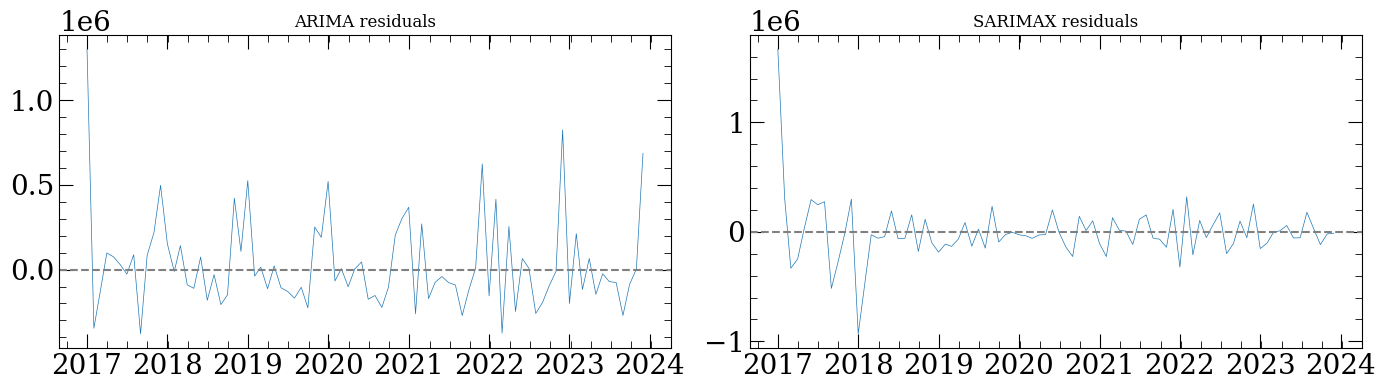

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(arima.resid, linewidth=0.5)
axes[0].axhline(y=0, color="gray", linestyle="--")
axes[0].set_title("ARIMA residuals")
axes[1].plot(sarimax.resid, linewidth=0.5)
axes[1].axhline(y=0, color="gray", linestyle="--")
axes[1].set_title("SARIMAX residuals")
plt.tight_layout()
plt.show()

## ACF of Residuals

If there's still autocorrelation in the residuals, the model left patterns on the table. We check with the ACF.

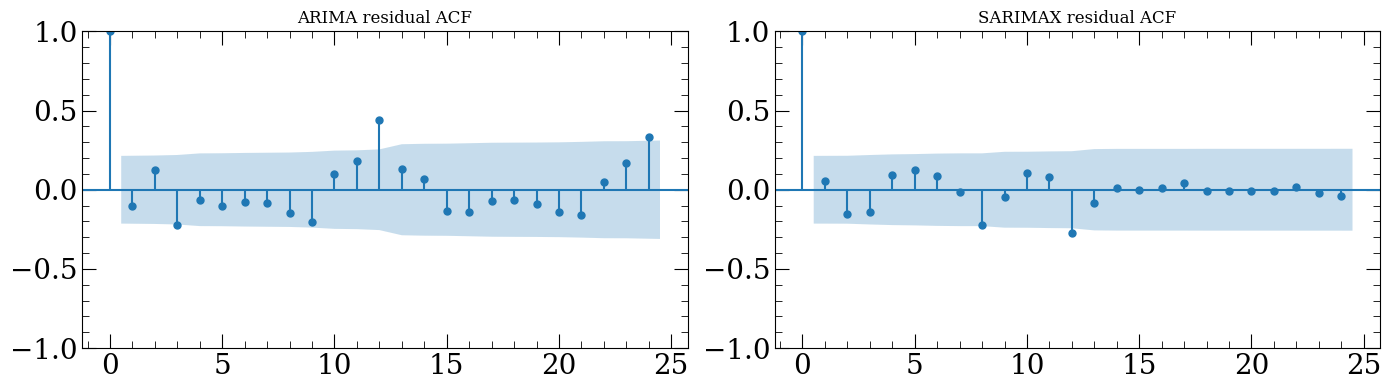

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(arima.resid, ax=axes[0], lags=24)
axes[0].set_title("ARIMA residual ACF")
plot_acf(sarimax.resid, ax=axes[1], lags=24)
axes[1].set_title("SARIMAX residual ACF")
plt.tight_layout()
plt.show()

## Ljung-Box Test

The ACF gives you a visual, but the Ljung-Box test gives you a definitive number. It tests whether there's significant autocorrelation left in the residuals.

- **p-value > 0.05**: Residuals look like white noise. Model captured the structure.
- **p-value < 0.05**: Residuals still have pattern. Model missed something.

In [6]:
for name, fitted in [("ARIMA", arima), ("SARIMAX", sarimax)]:
    lb = acorr_ljungbox(fitted.resid, lags=[12], return_df=True)
    _, norm_p = stats.normaltest(fitted.resid.dropna())
    print(f"{name}:")
    print(f"  AIC: {fitted.aic:.1f}  BIC: {fitted.bic:.1f}")
    print(f"  Ljung-Box p (lag 12): {lb['lb_pvalue'].values[0]:.4f}")
    print(f"  Normality p: {norm_p:.4f}")
    print()

ARIMA:
  AIC: 2300.8  BIC: 2310.5
  Ljung-Box p (lag 12): 0.0001
  Normality p: 0.0000

SARIMAX:
  AIC: 1895.6  BIC: 1909.2
  Ljung-Box p (lag 12): 0.0507
  Normality p: 0.0000



## Results and What They Mean

| Model | Ljung-Box p | Verdict |
|-------|-------------|---------|
| ARIMA | **0.0001** | ❌ **FAILED** - Significant autocorrelation remains |
| SARIMAX | **0.0507** | ⚠️ **BORDERLINE** - Just barely passes |

### Why ARIMA Failed

This is electricity demand data. It has **two** predictable patterns:
1. **Seasonality** - demand cycles yearly (higher in summer/winter for AC/heating)
2. **Temperature correlation** - demand spikes on hot and cold days

The ARIMA model has **neither** of these. It's just autoregressive with differencing. So of course it leaves massive structure in the residuals—it never tried to model the seasonal pattern or use temperature information.

### Why SARIMAX Succeeded (Mostly)

The SARIMAX includes:
- `seasonal_order=(1, 1, 1, 12)` → captures the yearly cycle
- `exog=train["avg_temp_f"]` → uses temperature as a predictor

That's why its Ljung-Box p-value is ~0.05 and ARIMA's is 0.0001. The SARIMAX actually modeled the sources of variation; ARIMA ignored them.

### The Normality Problem (Both Models)

Both models fail the normality test (p ≈ 0). This means the residuals have fat tails or skew. **What this means for you:** prediction intervals are approximations. The intervals aren't wrong, but "95% confidence" might actually be 90% or 98%.

### Actionable Takeaways

1. **Ljung-Box p < 0.05** → Your model is incomplete. Add seasonal terms, exogenous variables, or change the differencing.
2. **Ljung-Box p just above 0.05** → Acceptable but monitor. The model captured most structure.
3. **Normality fails** → Prediction intervals are rough guides, not exact probabilities.
4. **Always compare information criteria** → Lower AIC/BIC means better fit for the complexity. SARIMAX wins here (1895 vs 2300).